### Treatment Effect Estimation

In [1]:
import pandas as pd

#### load matched cohort 

In [2]:
df_matched = pd.read_csv("../data/matched_cohort_1to1.csv")
df_matched

,age,female,extranod,stage2,medwidsi_S,medwidsi_N,chemo,time,status
0,64.00,1,0,0,0,1,1,3.700,2
1,20.00,0,0,1,0,0,1,16.800,2
2,64.00,0,0,1,0,1,1,0.003,1
3,54.00,0,0,0,0,1,1,10.500,0
4,64.07,0,0,0,0,1,1,14.000,2
...,...,...,...,...,...,...,...,...,...
371,27.00,0,0,0,0,1,0,2.500,1
372,43.00,0,0,1,0,1,0,5.400,2
373,31.00,1,0,0,0,1,0,8.600,0
374,21.00,0,0,1,1,0,0,29.700,0


#### Initialize and fit PyTMLE

In [3]:
from pytmle import PyTMLE

target_times = [5.0, 10.0, 15.0, 20.0, 25.0, 30.0] # times at which treatment effect should be estimated

tmle = PyTMLE(df_matched, 
              col_event_times="time", 
              col_event_indicator="status", 
              col_group="chemo", 
              target_times=target_times, 
              g_comp=True,
              evalues_benchmark=False)

tmle.fit(save_models=True, 
         bootstrap=False, 
         n_jobs=-1)

/home/aweller/r4r-training/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Estimating propensity scores...
Estimating hazards and event-free survival...
Estimating censoring survival...


/home/aweller/r4r-training/.venv/lib/python3.12/site-packages/pytmle/initial_estimates_default_models.py:37: UserWarning: Default DeepHit model not available: No module named 'torch'. Will only cross-fit Cox PH and random survival forest.
  warnings.warn(


Starting TMLE update loop...
TMLE converged at step 63.


(<Figure size 1400x700 with 2 Axes>,
 array([<Axes: title={'center': 'Event 1'}, xlabel='Time', ylabel='Predicted Risk'>,
        <Axes: title={'center': 'Event 2'}, xlabel='Time', ylabel='Predicted Risk'>],
       dtype=object))

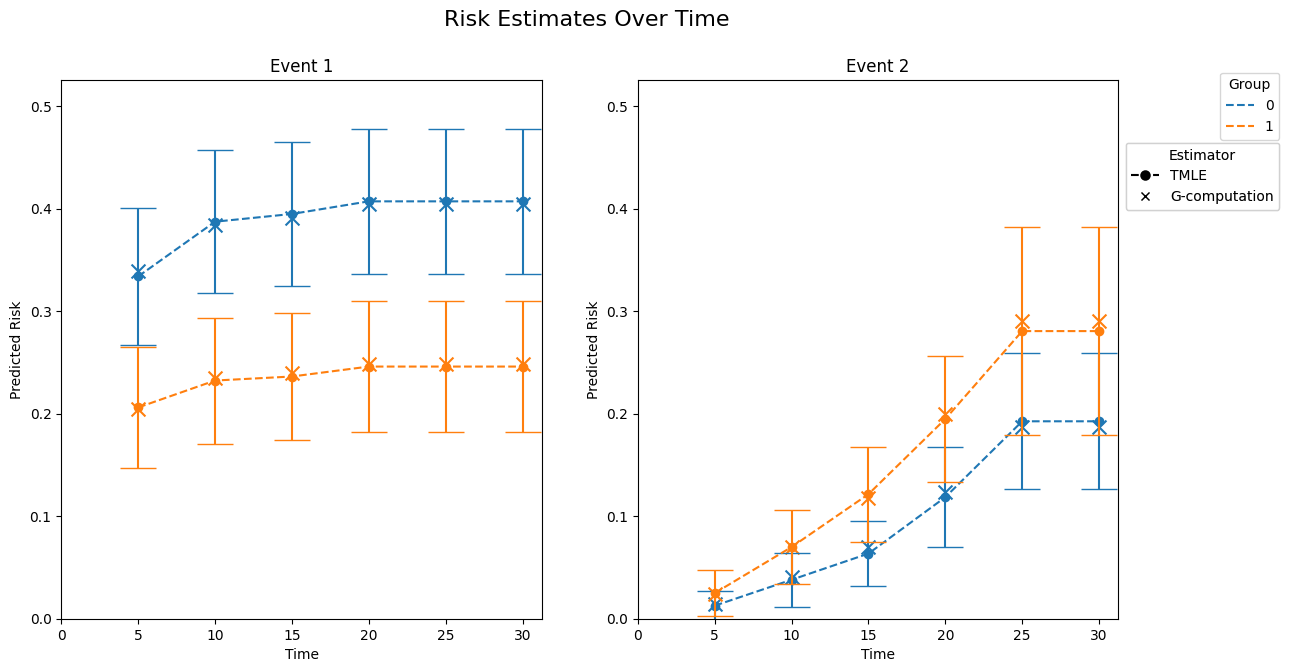

In [4]:
tmle.plot(g_comp=True, use_bootstrap=False)

Several other plots can be shown, see https://github.com/SCAI-BIO/pytmle